# Analyze deconvolved gene expression

In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'


In [15]:
from pipeline.expression_analysis import load_deconvolved_gene_expression, \
    plot_volcano_cg1_dg1

deconvolved_genes_F = load_deconvolved_gene_expression(output_directory)

In [20]:
deconvolved_genes_F

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
YAL009W,5.385011,5.364466,5.343270,5.322569,5.302743,5.284187,5.268062,5.255354,5.247448,5.245611,...,5.110950,5.109023,5.106661,5.103907,5.100736,5.097120,5.093043,5.088492,5.083528,5.385011
YDL145C,7.982594,7.962864,7.942834,7.923598,7.905528,7.888991,7.875153,7.865037,7.859976,7.861193,...,8.005825,7.980858,7.955779,7.931382,7.908163,7.886403,7.866570,7.849004,7.833697,7.982594
YBL104C,4.730633,4.736403,4.742773,4.750066,4.758462,4.768203,4.779329,4.791747,4.805636,4.821121,...,4.907172,4.906594,4.906042,4.905519,4.905042,4.904628,4.904291,4.904042,4.903878,4.730633
YAL031C,4.797436,4.766750,4.733741,4.697815,4.658503,4.615134,4.568092,4.518139,4.465287,4.409683,...,3.935635,3.943689,3.952199,3.961143,3.970322,3.979521,3.988534,3.997164,4.005397,4.797436
YAL022C,5.139236,5.156870,5.177222,5.201652,5.230705,5.265127,5.305455,5.351747,5.404919,5.465730,...,5.452663,5.468084,5.485541,5.504844,5.525820,5.548306,5.572080,5.596908,5.622557,5.139236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YAR042W,5.054116,5.053037,5.052328,5.052735,5.054585,5.058275,5.064264,5.072810,5.084597,5.100207,...,5.162635,5.160196,5.157483,5.154486,5.151236,5.147780,5.144140,5.140342,5.136421,5.054116
YAR031W,2.266573,2.119344,1.966169,1.817720,1.684063,1.575812,1.493445,1.433985,1.398250,1.385659,...,2.936309,2.940364,2.941690,2.939948,2.934447,2.924710,2.909826,2.888996,2.862847,2.266573
YDL183C,3.085295,3.088899,3.092531,3.097079,3.103262,3.111985,3.123157,3.136280,3.151909,3.170374,...,3.417106,3.406746,3.395707,3.384175,3.372309,3.360260,3.348159,3.336119,3.324235,3.085295
YAL067W-A,0.000128,0.000127,0.000127,0.000127,0.000127,0.000127,0.000127,0.000127,0.000126,0.000126,...,0.000125,0.000125,0.000125,0.000125,0.000125,0.000125,0.000125,0.000125,0.000125,0.000128


In [18]:
deconvolved_genes_F.shape

(272, 149)

Shifting mu0, gamma1, and gamma2, for alpha...


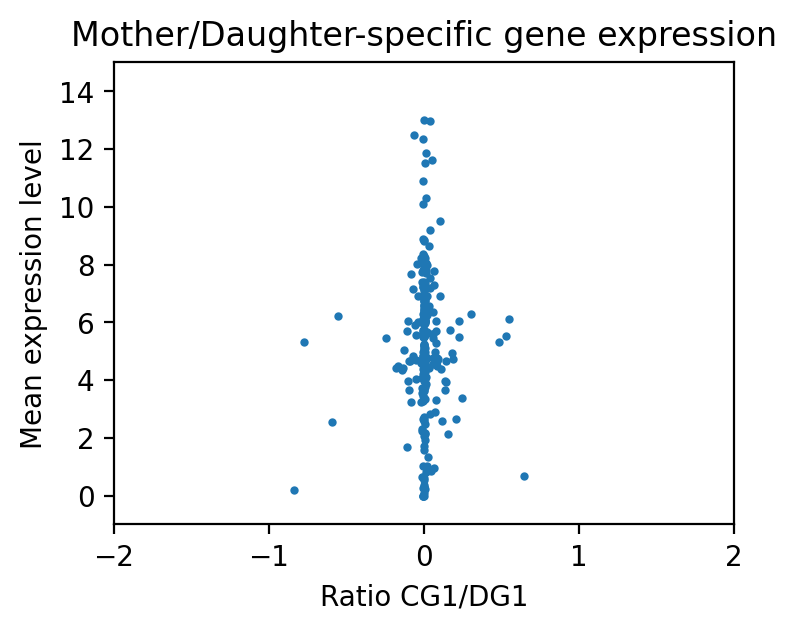

In [37]:
from src.CombinedReplicationDeconvolution import load_config_from_replication_runs
config1, config2 = load_config_from_replication_runs(output_directory, 4, mode='expression')

cg1_dg1_data = plot_volcano_cg1_dg1(deconvolved_genes_F, config1)

In [38]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()

genes[['gene']].join(cg1_dg1_data[cg1_dg1_data['max_ratio'] > 0.5], how='inner')


,gene,avg_occ,max_ratio
YAL064W,YAL064W,0.675953,0.647872
YAL040C,CLN3,5.522412,0.528822
YAL022C,FUN26,6.108623,0.547623
